# Layer 2 — Consumer Wearable Bridge Analysis

Applies the Layer 1 SVM model (trained on Physionet ECG data) to personal Apple Watch
heart rate and HRV data. Quantifies the signal gap between clinical and consumer-grade
sources, generates anomaly probability scores, and tests whether scores are elevated
around the clinical anchor date (June 18, 2025).

**Prerequisite:** `03_modelling.ipynb` must be run first — this notebook loads the saved
SVM model, scaler, and Physionet feature matrix from Layer 1.

**Calls:** `src/apple_watch_features.py` — `build_apple_watch_feature_matrix()`

## Cell 1 — Imports, Paths, Constants, and Layer 1 Artifacts

Loads all dependencies, defines project paths and locked window parameters,
and loads the three Layer 1 artifacts needed for Layer 2 analysis:
- `selected_model.joblib` — fitted SVM classifier
- `scaler.joblib` — fitted StandardScaler (trained on Layer 1 training data only)
- `physionet_features.csv` — Layer 1 feature matrix (for distribution comparison)

**Output paths:**
- `PROC_DIR` → `data/processed/` (for apple_watch_features.csv)
- `LAYER2_DIR` → `outputs/layer2/` (for gap_quantification.csv, probability_scores.csv, mann_whitney_results.csv)

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats

# ── Project root and src/ access ─────────────────────────────
PROJECT_ROOT = r'C:\Projects\GA Capstone Project'
sys.path.insert(0, PROJECT_ROOT)

from src.apple_watch_features import build_apple_watch_feature_matrix

# ── Input paths ──────────────────────────────────────────────
HR_PATH  = os.path.join(PROJECT_ROOT, 'data', 'processed', 'heart_rate_clean.csv')
HRV_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'hrv_clean.csv')

# ── Output paths ─────────────────────────────────────────────
PROC_DIR   = os.path.join(PROJECT_ROOT, 'data', 'processed')
LAYER2_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'layer2')
FIGURE_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'figures')

os.makedirs(LAYER2_DIR, exist_ok=True)

# ── Locked window parameters ─────────────────────────────────
WINDOW_SIZE_MINUTES = 30
STEP_SIZE_MINUTES   = 15
MIN_READINGS        = 10

# ── Locked feature column order ──────────────────────────────
FEATURE_COLS = [
    'rmssd', 'sdnn', 'mean_rr', 'pnn50',
    'hr_mean', 'hr_std', 'rr_skewness', 'rr_kurtosis'
]

# ── Load Layer 1 artifacts ───────────────────────────────────
MODEL_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'models')

scaler = joblib.load(os.path.join(MODEL_DIR, 'scaler.joblib'))
model  = joblib.load(os.path.join(MODEL_DIR, 'selected_model.joblib'))

physionet_features = pd.read_csv(
    os.path.join(PROC_DIR, 'physionet_features.csv')
)

# ── Confirmation ─────────────────────────────────────────────
print('Layer 1 artifacts loaded:')
print(f'  Physionet features shape: {physionet_features.shape}')
print(f'  Scaler type:             {type(scaler).__name__}')
print(f'  Model type:              {type(model).__name__}')
print(f'  LAYER2_DIR exists:       {os.path.isdir(LAYER2_DIR)}')

Layer 1 artifacts loaded:
  Physionet features shape: (8187, 11)
  Scaler type:             StandardScaler
  Model type:              SVC
  LAYER2_DIR exists:       True


## Cell 2 — Build Apple Watch Feature Matrix

Calls `build_apple_watch_feature_matrix()` with locked window parameters
(30 min window, 15 min step, min 10 readings). The function extracts HR and HRV
features, then merges them using a vectorised interval join — only windows with
both sufficient HR readings and at least one HRV record are retained.

Validates the resulting matrix for missing values before saving to
`data/processed/apple_watch_features.csv`.

**Calls:** `src/apple_watch_features.py` — `build_apple_watch_feature_matrix()`
**Output:** `data/processed/apple_watch_features.csv`

In [ ]:
# Calls: src/apple_watch_features.build_apple_watch_feature_matrix()
# Input: data/processed/heart_rate_clean.csv, data/processed/hrv_clean.csv
# Output: data/processed/apple_watch_features.csv

aw_features = build_apple_watch_feature_matrix(
    hr_path=HR_PATH,
    hrv_path=HRV_PATH,
    window_size_minutes=WINDOW_SIZE_MINUTES,
    step_size_minutes=STEP_SIZE_MINUTES,
    min_readings=MIN_READINGS
)

# ── Missing value check ─────────────────────────────────────
missing = aw_features[FEATURE_COLS].isnull().sum().sum()
print(f"\nMissing values across 8 features: {missing}")

if missing > 0:
    null_counts = aw_features[FEATURE_COLS].isnull().sum()
    print("\nWARNING — features with missing values:")
    print(null_counts[null_counts > 0])
    raise ValueError(
        f"Feature matrix contains {missing} missing values. "
        "Cannot save — investigate before proceeding."
    )

# ── Save ─────────────────────────────────────────────────────
aw_save_path = os.path.join(PROC_DIR, 'apple_watch_features.csv')
aw_features.to_csv(aw_save_path, index=False)
print(f"\nSaved: {aw_save_path}")

# ── Summary ──────────────────────────────────────────────────
print(f"\nApple Watch feature matrix shape: {aw_features.shape}")
print(f"Date range: {aw_features['window_start'].min()} → {aw_features['window_end'].max()}")
print(f"\nAnchor period distribution:")
print(aw_features['anchor_period'].value_counts().sort_index())
print()
aw_features.head()

## Cell 3 — Apple Watch vs Physionet Feature Distributions

Visual side-by-side comparison of all 8 feature distributions between Layer 1
(Physionet ECG, 8,187 records) and Layer 2 (Apple Watch, 1,997 windows).
Histograms are density-normalised so the different sample sizes are comparable.

Subplot order follows `FEATURE_COLS` exactly, matching the KS results table in Cell 4.

**Output:** `outputs/figures/aw_vs_physionet_distributions.png`

Saved: C:\Projects\GA Capstone Project\outputs\figures\aw_vs_physionet_distributions.png


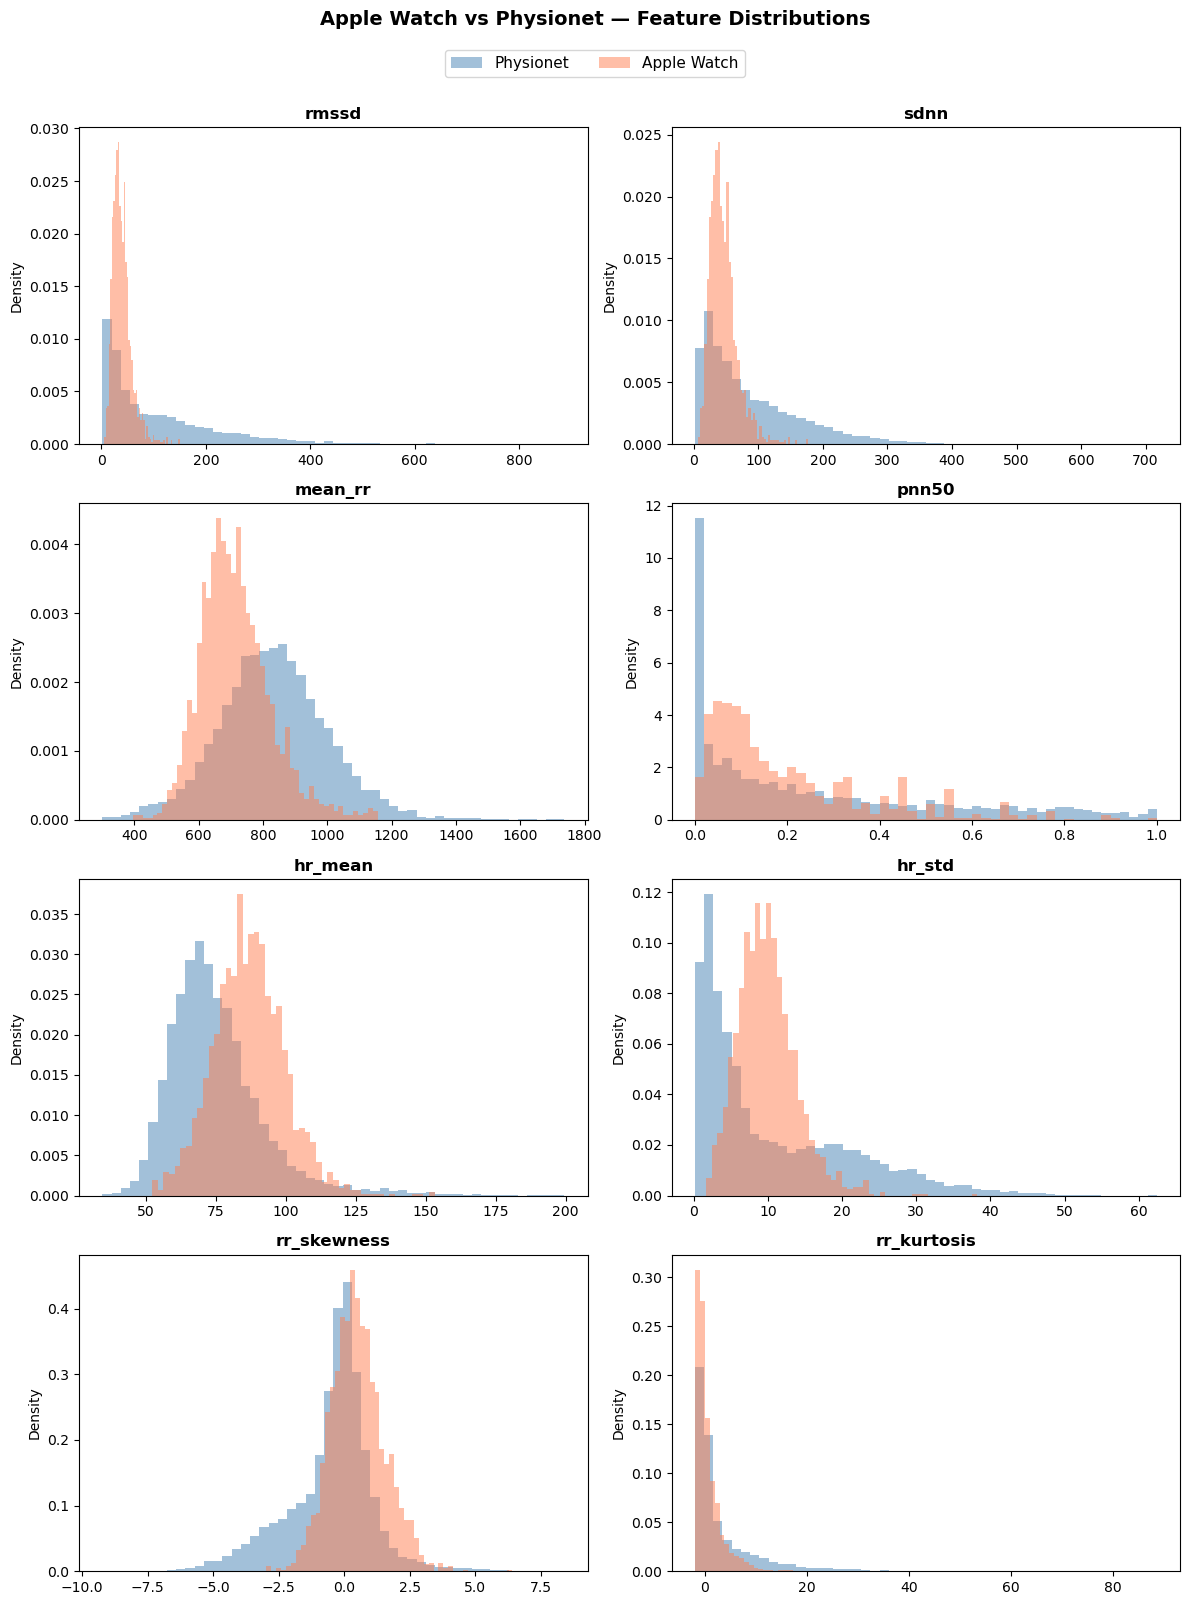

In [ ]:
# Output: outputs/figures/aw_vs_physionet_distributions.png

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]

    ax.hist(physionet_features[col].dropna(), bins=50, density=True,
            alpha=0.5, color='steelblue', label='Physionet')
    ax.hist(aw_features[col].dropna(), bins=50, density=True,
            alpha=0.5, color='coral', label='Apple Watch')

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Density')

# Single shared legend at the top
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2,
           fontsize=11, frameon=True, bbox_to_anchor=(0.5, 0.98))

fig.suptitle('Apple Watch vs Physionet — Feature Distributions',
             fontsize=14, fontweight='bold', y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.97])

fig_path = os.path.join(FIGURE_DIR, 'aw_vs_physionet_distributions.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f"Saved: {fig_path}")
plt.show()

## Cell 4 — KS Gap Quantification Per Feature

Runs two-sample Kolmogorov-Smirnov test for each of the 8 features, comparing
Physionet (8,187 records) against Apple Watch (1,997 windows). Quantifies the
distributional gap magnitude per feature and categorises into three bands:
- KS < 0.1 — small gap
- KS 0.1–0.3 — moderate gap
- KS > 0.3 — large gap

**Output:** `outputs/layer2/gap_quantification.csv`

In [ ]:
# Output: outputs/layer2/gap_quantification.csv

rows = []
for col in FEATURE_COLS:
    physio_vals = physionet_features[col].dropna().values
    aw_vals     = aw_features[col].dropna().values

    ks_stat, p_val = stats.ks_2samp(physio_vals, aw_vals)

    physio_med = np.median(physio_vals)
    aw_med     = np.median(aw_vals)
    direction  = 'AW higher' if aw_med >= physio_med else 'AW lower'

    rows.append({
        'feature':            col,
        'ks_statistic':       round(ks_stat, 4),
        'p_value':            p_val,
        'physionet_median':   round(physio_med, 4),
        'apple_watch_median': round(aw_med, 4),
        'direction':          direction
    })

gap_df = pd.DataFrame(rows)

# ── Save ─────────────────────────────────────────────────────
gap_path = os.path.join(LAYER2_DIR, 'gap_quantification.csv')
gap_df.to_csv(gap_path, index=False)
print(f"Saved: {gap_path}\n")

# ── Full table ───────────────────────────────────────────────
print("KS Gap Quantification — Physionet vs Apple Watch")
print("=" * 75)
print(gap_df.to_string(index=False))

# ── Summary by band ──────────────────────────────────────────
small    = gap_df.loc[gap_df['ks_statistic'] < 0.1,  'feature'].tolist()
moderate = gap_df.loc[(gap_df['ks_statistic'] >= 0.1) &
                      (gap_df['ks_statistic'] <= 0.3), 'feature'].tolist()
large    = gap_df.loc[gap_df['ks_statistic'] > 0.3,   'feature'].tolist()

print(f"\nGap summary:")
print(f"  Small (KS < 0.1):    {len(small)}  — {', '.join(small) if small else 'none'}")
print(f"  Moderate (0.1–0.3):  {len(moderate)}  — {', '.join(moderate) if moderate else 'none'}")
print(f"  Large (KS > 0.3):    {len(large)}  — {', '.join(large) if large else 'none'}")

Saved: C:\Projects\GA Capstone Project\outputs\layer2\gap_quantification.csv

KS Gap Quantification — Physionet vs Apple Watch
    feature  ks_statistic       p_value  physionet_median  apple_watch_median direction
      rmssd        0.4241 1.658702e-260           65.5416             35.5485  AW lower
       sdnn        0.3560 1.009568e-181           62.8530             41.8218  AW lower
    mean_rr        0.3900 4.195085e-219          830.7619            702.6285  AW lower
      pnn50        0.2100  1.696479e-62            0.1562              0.1333  AW lower
    hr_mean        0.4164 7.449300e-251           72.2229             86.7225 AW higher
     hr_std        0.3588 1.244405e-184            6.0907              9.5822 AW higher
rr_skewness        0.2970 1.337095e-125           -0.2051              0.4482 AW higher
rr_kurtosis        0.1925  1.631987e-52            0.4051             -0.2515  AW lower

Gap summary:
  Small (KS < 0.1):    0  — none
  Moderate (0.1–0.3):  3  — pnn50,

## Cell 5 — Apply Scaler and SVM, Generate Probability Scores

Applies the Layer 1 pipeline (StandardScaler → SVM) to the Apple Watch feature matrix.
The scaler is applied via `transform()` only — no re-fitting on Apple Watch data.
The SVM's `predict_proba()` produces anomaly scores (P(Abnormal)) for each window.

No re-training, no threshold adjustment, no domain adaptation. The scores represent
what the clinical model "thinks" about each Apple Watch window.

**Output:** `outputs/layer2/probability_scores.csv`

In [ ]:
# Output: outputs/layer2/probability_scores.csv

# ── Confirm feature name alignment ───────────────────────────
print(f"Scaler feature names: {list(scaler.feature_names_in_)}")
print(f"FEATURE_COLS:         {FEATURE_COLS}")
assert list(scaler.feature_names_in_) == FEATURE_COLS, \
    "Feature name mismatch between scaler and FEATURE_COLS"
print("Feature names match.\n")

# ── Scale features using Layer 1 scaler (transform only) ─────
X_aw = aw_features[FEATURE_COLS]
X_aw_scaled = pd.DataFrame(
    scaler.transform(X_aw), columns=FEATURE_COLS
)

# ── Generate anomaly probability scores ──────────────────────
anomaly_scores = model.predict_proba(X_aw_scaled)[:, 1]

# ── Build output DataFrame ───────────────────────────────────
scores_df = pd.DataFrame({
    'window_start':  aw_features['window_start'].values,
    'window_end':    aw_features['window_end'].values,
    'anomaly_score': np.round(anomaly_scores, 4),
    'anchor_period': aw_features['anchor_period'].values
})

# ── Save ─────────────────────────────────────────────────────
scores_path = os.path.join(LAYER2_DIR, 'probability_scores.csv')
scores_df.to_csv(scores_path, index=False)
print(f"Saved: {scores_path}\n")

# ── Overall score distribution ───────────────────────────────
print("Anomaly Score Distribution (all windows)")
print("=" * 45)
print(f"  Count:  {len(scores_df):,}")
print(f"  Mean:   {anomaly_scores.mean():.4f}")
print(f"  Std:    {anomaly_scores.std():.4f}")
print(f"  Median: {np.median(anomaly_scores):.4f}")
print(f"  Min:    {anomaly_scores.min():.4f}")
print(f"  Max:    {anomaly_scores.max():.4f}")

# ── Per anchor period summary ────────────────────────────────
print("\nPer Anchor Period Summary")
print("=" * 55)
period_summary = (
    scores_df
    .groupby('anchor_period')['anomaly_score']
    .agg(['count', 'mean', 'std', 'median'])
    .reindex(['baseline', 'pre_anchor', 'post_anchor', 'follow_up'])
    .round(4)
)
print(period_summary.to_string())

Scaler feature names: ['rmssd', 'sdnn', 'mean_rr', 'pnn50', 'hr_mean', 'hr_std', 'rr_skewness', 'rr_kurtosis']
FEATURE_COLS:         ['rmssd', 'sdnn', 'mean_rr', 'pnn50', 'hr_mean', 'hr_std', 'rr_skewness', 'rr_kurtosis']
Feature names match.

Saved: C:\Projects\GA Capstone Project\outputs\layer2\probability_scores.csv

Anomaly Score Distribution (all windows)
  Count:  1,997
  Mean:   0.2356
  Std:    0.2532
  Median: 0.1186
  Min:    0.0176
  Max:    1.0000

Per Anchor Period Summary
               count    mean     std  median
anchor_period                               
baseline        1758  0.2385  0.2546  0.1197
pre_anchor        95  0.1595  0.1539  0.1035
post_anchor       29  0.1770  0.1593  0.1005
follow_up        115  0.2678  0.3020  0.1209


## Cell 6 — One-Sided Mann-Whitney U Per Anchor Period

Tests whether anomaly scores in each non-baseline anchor period are significantly
elevated above baseline (pre-registered one-sided test, `alternative='greater'`).
Rank-biserial correlation computed as effect size: r = 1 - (2U)/(n1 * n2).

**Output:** `outputs/layer2/mann_whitney_results.csv`

In [ ]:
# Output: outputs/layer2/mann_whitney_results.csv

baseline_scores = scores_df.loc[
    scores_df['anchor_period'] == 'baseline', 'anomaly_score'
].values

test_periods = ['pre_anchor', 'post_anchor', 'follow_up']
rows = []

for period in test_periods:
    period_scores = scores_df.loc[
        scores_df['anchor_period'] == period, 'anomaly_score'
    ].values

    U, p = stats.mannwhitneyu(
        period_scores, baseline_scores, alternative='greater'
    )

    n1, n2 = len(period_scores), len(baseline_scores)
    r = 1 - (2 * U) / (n1 * n2)

    direction = 'higher' if np.median(period_scores) > np.median(baseline_scores) else 'lower'

    rows.append({
        'period':          period,
        'n':               n1,
        'median_score':    round(np.median(period_scores), 4),
        'U_statistic':     U,
        'p_value':         p,
        'effect_size_r':   round(r, 4),
        'significant':     p < 0.05,
        'direction':       direction
    })

mw_df = pd.DataFrame(rows)

# ── Save ─────────────────────────────────────────────────────
mw_path = os.path.join(LAYER2_DIR, 'mann_whitney_results.csv')
mw_df.to_csv(mw_path, index=False)
print(f"Saved: {mw_path}\n")

# ── Full results table ───────────────────────────────────────
print("Mann-Whitney U — Anchor Period vs Baseline (one-sided, greater)")
print(f"Baseline: n={len(baseline_scores)}, median={np.median(baseline_scores):.4f}")
print("=" * 80)
print(mw_df.to_string(index=False))

Saved: C:\Projects\GA Capstone Project\outputs\layer2\mann_whitney_results.csv

Mann-Whitney U — Anchor Period vs Baseline (one-sided, greater)
Baseline: n=1758, median=0.1197
     period   n  median_score  U_statistic  p_value  effect_size_r  significant direction
 pre_anchor  95        0.1035      74785.0 0.956987         0.1044        False     lower
post_anchor  29        0.1005      22759.5 0.839216         0.1072        False     lower
  follow_up 115        0.1209      97527.5 0.736705         0.0352        False    higher


## Cell 7 — Tier Assessment Summary

Summarises the three-tier evaluation framework for the Apple Watch N=1 case study.
Each tier builds on the previous: Tier 1 checks pipeline execution, Tier 2 tests
for statistically elevated anomaly scores around the anchor date, and Tier 3
evaluates screening feasibility (conditional on Tier 2 passing).

**Output:** `outputs/layer2/tier_assessment.csv`

In [ ]:
# Output: outputs/layer2/tier_assessment.csv

tier_data = [
    {
        "tier": 1,
        "criterion": "Pipeline execution and gap quantification interpretable",
        "result": "PASS",
        "evidence": "1,997 windows generated. KS statistics computed for all 8 features. 5 large (KS>0.3), 3 moderate (0.1-0.3), 0 small."
    },
    {
        "tier": 2,
        "criterion": "At least one anchor period significantly elevated above baseline (Mann-Whitney p<0.05)",
        "result": "FAIL",
        "evidence": "pre_anchor p=0.957, post_anchor p=0.839, follow_up p=0.737. No period elevated above baseline."
    },
    {
        "tier": 3,
        "criterion": "Screening feasibility demonstrated (conditional on Tier 2 pass)",
        "result": "FAIL",
        "evidence": "Tier 2 not passed. Tier 3 cannot be evaluated."
    }
]

tier_df = pd.DataFrame(tier_data)

output_path = os.path.join(LAYER2_DIR, "tier_assessment.csv")
os.makedirs(LAYER2_DIR, exist_ok=True)
tier_df.to_csv(output_path, index=False)

print("Tier assessment saved.")
print(tier_df[["tier", "result"]].to_string(index=False))

Tier assessment saved.
 tier result
    1   PASS
    2   FAIL
    3   FAIL
